# 📊 Simple Linear Regression: From Intuition to Math

## 🧠 The Core Intuition (Layman's Terms)
Imagine you are trying to predict how much a house will sell for based on its size. You know that bigger houses generally cost more, but you want to know **exactly how much more**. 

Simple Linear Regression is just a mathematical way of drawing the "best possible straight line" through your data to answer that question. 
- If you know the size of the house (**Predictor / $X$**), you use the line to predict the price (**Response / $Y$**).

Even though modern AI and Deep Learning get all the hype, Linear Regression is the "Hello World" of Machine Learning. It is the foundational building block for almost all complex statistical models!

### 🗺️ Conceptual Flow Diagram
```mermaid
graph TD
    A[Real World Population] -->|True but Unknown| B(Population Line: Y = β0 + β1X + ε)
    A -->|We take a Sample| C[Sample Data]
    C -->|Minimize Mistakes RSS| D(Least Squares Line: ŷ = β̂0 + β̂1x)
    D -->|How sure are we?| E[Standard Error & p-value]
    D -->|How good is the fit?| F[RSE & R²]
```

In [4]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.datasets import get_rdataset

# Set visualization style
sns.set_theme(style="whitegrid")

# Load the Advertising dataset from the ISLR package
advertising = pd.read_csv(r"D:\Projects\ISLP_withApplicationsInPython\data\Advertising.csv")

In [5]:
# Display the first few rows
display(advertising.head())

,Unnamed: 0,TV,radio,newspaper,sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [6]:
# For Simple Linear Regression, let's focus on just ONE predictor: TV budget
X = advertising['TV']
y = advertising['sales']

## 1. Simple Linear Regression
Simple linear regression predicts a quantitative response $Y$ on the basis of a **single predictor variable** $X$. It assumes there is approximately a linear relationship between them. Using an **Advertising Dataset** (predicting `sales` based on `TV` budget):

1. **Is there a relationship** between advertising and sales?
2. **How strong** is the relationship?
3. **Which media** drive sales?
4. **How large** is each medium's effect?
5. **How accurately** can we predict future sales?
6. **Is the relationship linear**?
7. **Do the media interact** with each other?

### 💡 Think of Linear Regression as:
> The **"Hello World"** of Machine Learning - simple but foundational!



## 📐 1. The Mathematical Equation
We assume there is a straight-line relationship between $X$ and $Y$. We write this as:

$$ Y \approx \beta_0 + \beta_1 X $$

### 🔍 Detailed Term Breakdown:
*   **$Y$ (Response)**: The variable we want to predict (e.g., `sales`).
*   **$X$ (Predictor)**: The variable we base our prediction on (e.g., `TV` budget).
*   **$\beta_0$ (Intercept)**: The expected value of $Y$ when $X = 0$. 
    * *Layman:* If we spend $0 on TV ads, what are our baseline sales?
*   **$\beta_1$ (Slope)**: The average increase in $Y$ for a one-unit increase in $X$. 
    * *Layman:* For every $1,000 we spend on TV, how many extra units do we sell?
*   **$\approx$**: Read as "is approximately modeled as".

### 🎩 The "Hat" Notation
Because $\beta_0$ and $\beta_1$ are unknown truths about the universe, we must estimate them from our data. We put a "hat" on them to show they are estimates:
$$ \hat{y} = \hat{\beta}_0 + \hat{\beta}_1 x $$
*(Here, $\hat{y}$ is our **prediction** for a specific value $x$.)*

In [7]:
# Fit the simple linear regression model using statsmodels
# We add a constant to X to account for the intercept (β0)
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()

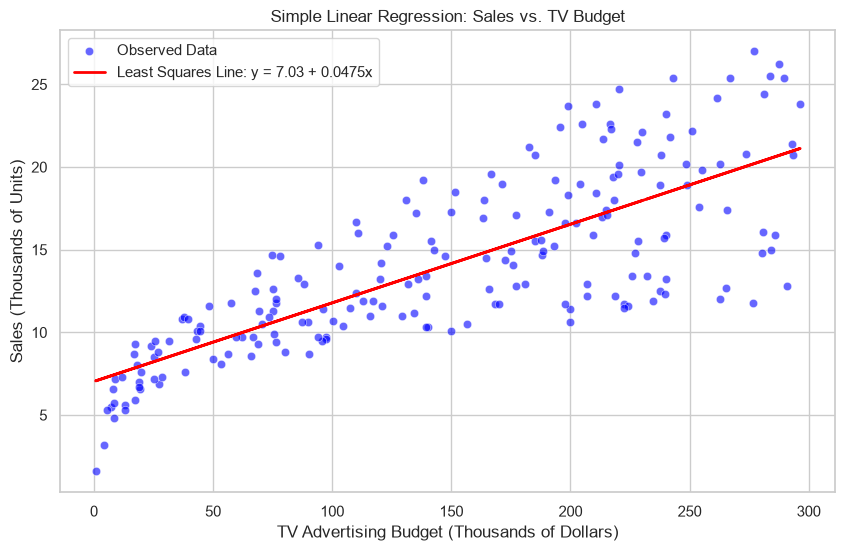

In [8]:
# Plot the data and the least squares regression line
plt.figure(figsize=(10, 6))
sns.scatterplot(x=X, y=y, alpha=0.6, label='Observed Data', color='blue')
plt.plot(X, model.predict(X_const), color='red', linewidth=2, label=f'Least Squares Line: y = {model.params["const"]:.2f} + {model.params["TV"]:.4f}x')

plt.title('Simple Linear Regression: Sales vs. TV Budget')
plt.xlabel('TV Advertising Budget (Thousands of Dollars)')
plt.ylabel('Sales (Thousands of Units)')
plt.legend()
plt.show()

## 🌪️ 2. The Error Term: Why the line isn't perfect
In the real world, data is messy. A straight line will never perfectly hit every single dot. We account for this by adding an **error term ($\epsilon$)**:

$$ Y = \beta_0 + \beta_1 X + \epsilon $$

### What is $\epsilon$ (Epsilon)?
Think of $\epsilon$ as a "catch-all" trash can for everything our simple model misses:
1. The true relationship might not be perfectly straight (non-linearity).
2. Other factors affect sales (like radio ads, competitor actions, or the economy) that we didn't include in $X$.
3. Random measurement errors.

We assume $\epsilon$ has a **mean of zero** (it's just random noise) and a constant variance ($\sigma^2$).

## 📉 3. Estimating the Coefficients (Least Squares)
How do we draw the "best" line? We want to minimize our mistakes. 

### The Residual ($e_i$)
For every data point, the model makes a prediction ($\hat{y}_i$). The difference between the actual value ($y_i$) and the prediction is the **residual**:

To measure TOTAL error, we:
1. Calculate residual for EVERY point
2. **Square** each one (makes everything positive, penalizes big errors)
3. **Sum** them all up

$$ e_i = y_i - \hat{y}_i $$
*(Layman: The vertical distance from the dot to the line.)*


### Residual Sum of Squares (RSS)
To measure the total mistake of the line, we square every residual (so negative and positive mistakes don't cancel out) and add them up:
$$ RSS = e_1^2 + e_2^2 + \dots + e_n^2 = \sum_{i=1}^n (y_i - \hat{\beta}_0 - \hat{\beta}_1 x_i)^2 $$

### 🧮 The Least Squares Formulas
Using calculus, we can find the exact $\hat{\beta}_0$ and $\hat{\beta}_1$ that make the RSS as small as possible:

$$ \hat{\beta}_1 = \frac{\sum_{i=1}^n (x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^n (x_i - \bar{x})^2} $$

**In plain English:**
- **Top (Numerator):** How X and Y move together (like covariance)
- **Bottom (Denominator):** How spread out X is (like variance)
- **Result:** The slope that minimizes error


### Intercept Formula
$$\hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x}$$

### 🔍 Deep Dive into the $\hat{\beta}_1$ Formula:
*   **$\bar{x}$ and $\bar{y}$**: The sample means (averages) of $X$ and $Y$.
*   **Numerator $\sum (x_i - \bar{x})(y_i - \bar{y})$**: This measures how $X$ and $Y$ move *together*. If $X$ is above average, is $Y$ also above average? (This is **Covariance**).
*   **Denominator $\sum (x_i - \bar{x})^2$**: This measures how spread out $X$ is on its own. (This is **Variance**).
*   **The Intuition**: The slope is simply "How much Y moves" divided by "How much X moves".
*   **The Centroid Rule**: The formula for $\hat{\beta}_0$ guarantees that the regression line **always** passes exactly through the point $(\bar{x}, \bar{y})$. The centroid of your data. This is like the line being "anchored" at the middle of all your dots!




Manual Intercept (β0): 7.0326
Manual Slope (β1): 0.0475


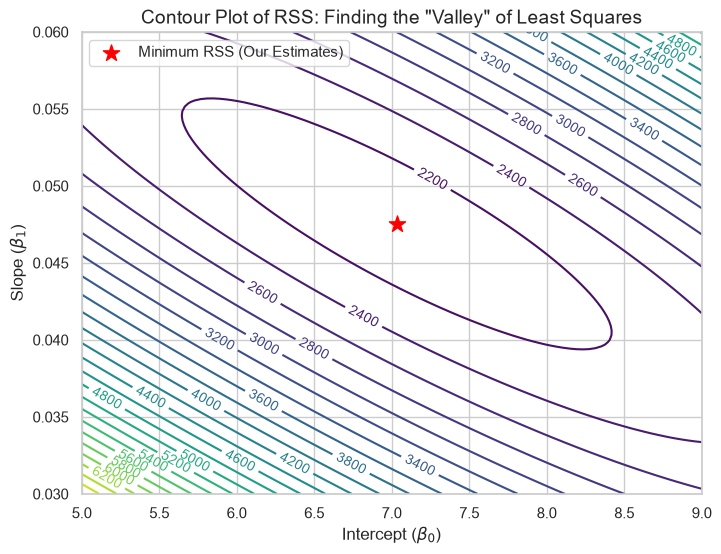

In [14]:
# 1. Manual Calculation of Coefficients
x_bar, y_bar = np.mean(X), np.mean(y)
beta1_hat = np.sum((X - x_bar) * (y - y_bar)) / np.sum((X - x_bar)**2)
beta0_hat = y_bar - beta1_hat * x_bar

print(f"Manual Intercept (β0): {beta0_hat:.4f}")
print(f"Manual Slope (β1): {beta1_hat:.4f}")

# 2. Visualizing RSS Minimization (Contour Plot)
# We create a grid of possible beta0 and beta1 values and calculate RSS for each
beta0_range = np.linspace(5, 9, 100)
beta1_range = np.linspace(0.03, 0.06, 100)
B0, B1 = np.meshgrid(beta0_range, beta1_range)
RSS_grid = np.zeros_like(B0)

for i in range(B0.shape[0]):
    for j in range(B0.shape[1]):
        y_pred = B0[i, j] + B1[i, j] * X
        RSS_grid[i, j] = np.sum((y - y_pred)**2)

plt.figure(figsize=(8, 6))
CS = plt.contour(B0, B1, RSS_grid, levels=30, cmap='viridis')
plt.clabel(CS, inline=1, fontsize=10)
plt.scatter([beta0_hat], [beta1_hat], color='red', s=150, zorder=5, marker='*', label='Minimum RSS (Our Estimates)')

plt.title('Contour Plot of RSS: Finding the "Valley" of Least Squares', fontsize=14)
plt.xlabel(r'Intercept ($\beta_0$)', fontsize=12)
plt.ylabel(r'Slope ($\beta_1$)', fontsize=12)
plt.legend()
plt.show()

## 3. Assessing the Accuracy of Coefficient Estimates

Our estimated line ($\hat{y}$) is based on a *sample* of data. If we took a different sample, we'd get a slightly different line. How close is our sample line to the **True Population Line**?


### 🌍 Population Regression Line vs. Least Squares Line
- **Population Regression Line**: $Y = \beta_0 + \beta_1 X + \epsilon$. This is the *true* best linear approximation in the entire population. It is **unobserved** and unknown.
- **Least Squares Line**: $\hat{y} = \hat{\beta}_0 + \hat{\beta}_1 x$. This is the line calculated from our specific sample. It is an *estimate* of the population line.

**The Error Term ($\epsilon$)**:
$$ Y = \beta_0 + \beta_1 X + \epsilon $$
- $\epsilon$ is a mean-zero random error term. It is a "catch-all" for what the simple linear model misses (e.g., the true relationship isn't perfectly linear, other unmeasured variables affect $Y$, measurement errors).
- We assume $\epsilon$ is independent of $X$ and has a constant variance $\sigma^2$.

### 📉 Standard Error (SE)

**Question:** If we collected another sample, how different would our estimate be?
**Answer:** The **Standard Error** tells us!

Just as the sample mean $\hat{\mu}$ has a standard error, our estimates $\hat{\beta}_0$ and $\hat{\beta}_1$ have standard errors, which measure how much they vary from sample to sample.

$$ SE(\hat{\beta}_1)^2 = \frac{\sigma^2}{\sum_{i=1}^n (x_i - \bar{x})^2} $$
- **Insight**: The standard error of the slope is **smaller** when the $x_i$ values are more spread out. Intuitively, if your data spans a wide range of $X$, you have more "leverage" to accurately pin down the slope.

$$ SE(\hat{\beta}_0)^2 = \sigma^2 \left[ \frac{1}{n} + \frac{\bar{x}^2}{\sum_{i=1}^n (x_i - \bar{x})^2} \right] $$
- **Insight**: If $\bar{x} = 0$, this reduces to $\sigma^2 / n$, which is exactly the variance formula for a sample mean!

*(Note: Since true $\sigma^2$ is unknown, we estimate it using the **Residual Standard Error (RSE)**: $RSE = \sqrt{RSS/(n-2)}$)*

**Key Insight:** The more spread out your X values, the **smaller** the SE → More accurate estimate!

### 🔍 Deep Dive into the SE Formula:
*   **$\sigma^2$**: The variance of the error term $\epsilon$. (More noise in the data = Higher SE = Less confident).
*   **Denominator $\sum (x_i - \bar{x})^2$**: The spread of $X$. 
    * *Layman Analogy:* Imagine trying to balance a seesaw. If you have two kids sitting right next to each other in the middle, it's hard to know exactly where the fulcrum is. But if one kid is at the very left edge and the other is at the very right edge (high spread), you know exactly where the balance point is! 
    * **Conclusion:** The more spread out your $X$ data is, the *smaller* your Standard Error, meaning you are much more confident in your slope.

### 📏 Confidence Intervals
A 95% Confidence Interval (CI) gives a range where we are 95% confident the *true* population parameter lies.
$$ \hat{\beta}_1 \pm 2 \cdot SE(\hat{\beta}_1) $$
- **Why "2"?** It roughly corresponds to the 97.5% quantile of the t-distribution with $n-2$ degrees of freedom. For large $n$, the t-distribution looks like a normal distribution, where 95% of the data falls within $\approx 2$ standard deviations of the mean.



### ⚖️ Hypothesis Testing

We want to know: Is $X$ actually related to $Y$, or did we just get lucky with our sample?

*   **Null Hypothesis ($H_0$)**: $\beta_1 = 0$ (There is NO relationship. The line is flat).
*   **Alternative Hypothesis ($H_a$)**: $\beta_1 \neq 0$ (There IS a relationship).


To test this, we calculate the **t-statistic**:
$$ t = \frac{\hat{\beta}_1 - 0}{SE(\hat{\beta}_1)} $$
- **Meaning**: This measures how many standard deviations our estimated slope $\hat{\beta}_1$ is away from zero. 

*"If the null hypothesis were true (no relationship), what is the probability of seeing a slope THIS extreme purely by random chance?"*

The p-value answers this question. **p-value** is the probability of observing a t-statistic THIS extreme if $H_0$ were true. A small p-value (typically $< 0.05$) means it's highly unlikely to see this association by pure chance, so we **reject $H_0$** and conclude a relationship exists.

*   **p-value < 0.05**: Extremely unlikely to be chance. We **reject $H_0$** and conclude a relationship exists.
*   **p-value > 0.05**: Plausible it's just noise. We **fail to reject $H_0$**.

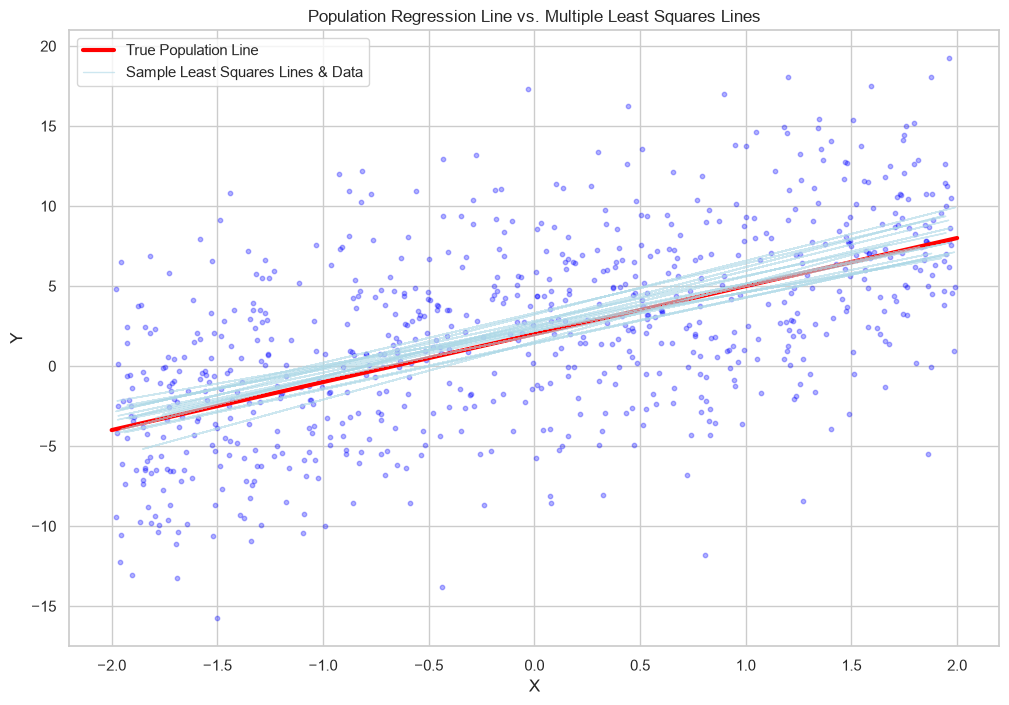

In [12]:
# Simulate 15 different datasets from the same true population model
np.random.seed(42)
true_beta0, true_beta1 = 2.0, 3.0
sigma = 5.0 # Standard deviation of the error term

plt.figure(figsize=(12, 8))
x_sim = np.linspace(-2, 2, 100)

# Plot the TRUE Population Regression Line (Unobserved in reality)
plt.plot(x_sim, true_beta0 + true_beta1 * x_sim, color='red', linewidth=3, label='True Population Line: Y = 2 + 3X')

# Plot 15 Least Squares lines from different random samples
for i in range(15):
    X_rand = np.random.uniform(-2, 2, 50)
    y_rand = true_beta0 + true_beta1 * X_rand + np.random.normal(0, sigma, 50)
    
    # Fit OLS
    X_sim_const = sm.add_constant(X_rand)
    sim_model = sm.OLS(y_rand, X_sim_const).fit()
    
    # Plot the least squares line and data points
    plt.plot(X_rand, sim_model.predict(X_sim_const), color='lightblue', alpha=0.6, linewidth=1)
    plt.scatter(X_rand, y_rand, color='blue', alpha=0.3, s=10)

plt.title('Population Regression Line vs. Multiple Least Squares Lines')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend(['True Population Line', 'Sample Least Squares Lines & Data'])
plt.show()

## 4. Assessing the Accuracy of the Model
Once we confirm a relationship exists, we must ask: *How well does this model actually fit the data?*

### 📏 Residual Standard Error (RSE)
$$ RSE = \sqrt{\frac{1}{n-2} RSS} = \sqrt{\frac{1}{n-2} \sum_{i=1}^n (y_i - \hat{y}_i)^2} $$
- **Meaning**: RSE is an estimate of $\sigma$ (the standard deviation of the error term $\epsilon$). It represents the average amount that the actual response $Y$ deviates from the true regression line.
- **Why $n-2$?**: This represents the **degrees of freedom**. We started with $n$ data points (n degrees of freedom) and spent 2 degrees of freedom to estimate $\beta_0$ and $\beta_1$.
- **Limitation**: It is measured in the units of $Y$, making it hard to judge if an RSE of "3.26" is "good" or "bad" without context.


### 📊 The $R^2$ Statistic
Because RSE is scale-dependent, we use $R^2$, which is a **proportion** always between 0 and 1.
$$ R^2 = \frac{TSS - RSS}{TSS} = 1 - \frac{RSS}{TSS} $$

**Term Breakdown:**
- **$TSS$ (Total Sum of Squares)**: $\sum (y_i - \bar{y})^2$. Measures the **total inherent variance** in $Y$ before we even build the model.
- **$RSS$ (Residual Sum of Squares)**: The variance **left unexplained** after fitting the regression.
- **$TSS - RSS$**: The variance in $Y$ that is successfully **explained** by our model.
- **Interpretation**: "An $R^2$ of 0.61 means that 61% of the variations in sales are explained by the TV budget. The other 39% is due to other factors (captured by $\epsilon$)."

*(Fun connection: In simple linear regression, $R^2$ is exactly equal to $r^2$, where $r$ is the Pearson correlation coefficient between $X$ and $Y$!)*

### Two Key Questions:
1. **How well does the model fit?** → R² Score
2. **How big are typical prediction errors?** → RSE


| R² Value | Meaning |
|----------|---------|
| **1.0** | Perfect fit (all points on line) |
| **0.9** | Excellent (90% variance explained) |
| **0.7** | Good |
| **0.5** | Moderate |
| **0.0** | No linear relationship |



In [13]:
# Extract RSE and R-squared from the statsmodels summary
rse = np.sqrt(model.mse_resid) # Mean Squared Error is RSS / (n-2)
r_squared = model.rsquared

# Calculate TSS manually to show the formula
tss = np.sum((y - np.mean(y))**2)
rss = np.sum((y - model.predict(X_const))**2)
r2_manual = 1 - (rss / tss)

print(f"Residual Standard Error (RSE): {rse:.4f}")
print(f"R-squared (from model): {r_squared:.4f}")
print(f"R-squared (manual calculation): {r2_manual:.4f}")

# Display the full statistical summary
print("\n--- Full Statsmodels Summary ---")
print(model.summary())

Residual Standard Error (RSE): 3.2587
R-squared (from model): 0.6119
R-squared (manual calculation): 0.6119

--- Full Statsmodels Summary ---
                            OLS Regression Results                            
Dep. Variable:                  sales   R-squared:                       0.612
Model:                            OLS   Adj. R-squared:                  0.610
Method:                 Least Squares   F-statistic:                     312.1
Date:                Fri, 19 Jun 2026   Prob (F-statistic):           1.47e-42
Time:                        12:38:59   Log-Likelihood:                -519.05
No. Observations:                 200   AIC:                             1042.
Df Residuals:                     198   BIC:                             1049.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025  

## 🎤 Interview Questions & Explanations

**Q1: What is the fundamental difference between the Population Regression Line and the Least Squares Line?**
> **Answer:** The population regression line represents the *true* underlying relationship between $X$ and $Y$ in the entire population, which is almost always unknown. The least squares line is the *estimate* of that true line, calculated using a specific sample of data. If we took 100 different samples, we would get 100 different least squares lines, but they would all be estimating the exact same, unchanging population regression line.

**Q2: Why do we divide by $n-2$ instead of $n$ when calculating the Residual Standard Error (RSE)?**
> **Answer:** We divide by $n-2$ to account for the **degrees of freedom**. To calculate the residuals, we first had to estimate two parameters from the data: the intercept ($\beta_0$) and the slope ($\beta_1$). Estimating these parameters uses up 2 degrees of freedom, leaving $n-2$ independent pieces of information to estimate the variance of the errors.

**Q3: How does the spread of the predictor variable $X$ affect the standard error of the slope ($\hat{\beta}_1$)?**
> **Answer:** Looking at the formula $SE(\hat{\beta}_1)^2 = \frac{\sigma^2}{\sum (x_i - \bar{x})^2}$, the spread of $X$ is in the denominator. If the $X$ values are highly spread out, the denominator becomes very large, which makes the standard error *smaller*. Intuitively, if you have data points scattered across a wide range of $X$, you have much more "leverage" to accurately pin down the slope of the line compared to data points clustered tightly together.

**Q4: If the p-value for $\hat{\beta}_1$ is 0.03, what does that actually mean in plain English?**
> **Answer:** It means that *if* there were truly zero relationship between $X$ and $Y$ in the population (the null hypothesis), there would only be a 3% probability of observing a sample slope ($\hat{\beta}_1$) as extreme as the one we got purely by random chance. Because 3% is very low (typically below the 5% threshold), we reject the null hypothesis and conclude that a statistically significant relationship exists.

**Q5: Can the $R^2$ statistic be negative in Simple Linear Regression?**
> **Answer:** No. In standard Ordinary Least Squares (OLS) simple linear regression, $R^2$ is bounded between 0 and 1. This is because the least squares line is mathematically guaranteed to fit the data at least as well as a flat horizontal line at the mean of $Y$ (which would result in $RSS = TSS$ and $R^2 = 0$). Therefore, $RSS$ can never be greater than $TSS$. *(Note: $R^2$ can be negative in non-linear models or if you force the intercept to be zero, but not in standard SLR).*



### Q6: What is the difference between the Error term ($\epsilon$) and the Residual ($e$)?
> **Answer:** 
> *   **$\epsilon$ (Error)** is theoretical. It represents the distance from a data point to the *True Population Line*. Because we never know the true population line, we can never observe $\epsilon$.
> *   **$e$ (Residual)** is observable. It is the vertical distance from a data point to our *Estimated Least Squares Line*. 

### Q7: Why do we square the residuals (RSS) instead of just taking the absolute value?
> **Answer:** 
> 1. **Math:** Squaring makes the function continuously differentiable, allowing us to use calculus to find a clean, closed-form solution for the coefficients.
> 2. **Penalty:** Squaring heavily penalizes large outliers. A residual of 10 becomes 100, forcing the regression line to pay attention to extreme points rather than ignoring them.
> 3. **Statistics:** It ties perfectly into the concept of variance and the Gaussian (Normal) distribution.

### Q8: If the spread of my X values increases, what happens to the Standard Error of the slope?
> **Answer:** It decreases! Look at the denominator of the SE formula: $\sum (x_i - \bar{x})^2$. If $X$ is highly spread out, this denominator gets massive, which drives the overall Standard Error down. Intuitively, having data points spread far apart gives the regression line more "leverage" to accurately lock onto the true slope.



## 🧠 Fun Facts about Linear Regression

1. 🧬 **"Regression to the Mean"**: The term "regression" was coined by **Francis Galton** in the 19th century while studying the heights of parents and their children. He noticed that extremely tall parents tended to have children who were shorter than them (closer to the average), and extremely short parents tended to have children taller than them. He called this phenomenon "regression to mediocrity" (now known as regression to the mean). The mathematical method we use today inherited his name!
2. 🧮 **The Math War**: The method of Least Squares was independently developed and published by two mathematical giants: **Adrien-Marie Legendre** (in 1805) and **Carl Friedrich Gauss** (in 1809). Gauss claimed he had been using it since 1795, leading to a bitter historical priority dispute.
3. 📈 **The Magic of $R^2$**: In simple linear regression, you don't actually need to calculate TSS and RSS to find $R^2$. If you simply calculate the Pearson correlation coefficient ($r$) between $X$ and $Y$, **$R^2$ is exactly equal to $r^2$**. 
4. 📏 **The Centroid Rule**: No matter how messy or scattered your data is, the least squares regression line will **always** pass exactly through the point $(\bar{x}, \bar{y})$—the centroid (average) of your dataset.